In [2]:
# Базовые библиотеки для воспроизводимости, анализа и визуализации.
import random
from typing import Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

import datasets
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import transformers
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)


# -----------------------
# Воспроизводимость
# -----------------------
RANDOM_STATE = 42
def set_seed(seed: int = RANDOM_STATE) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)

# -----------------------
# Устройство
# -----------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print('torch:', torch.__version__)
print('datasets:',datasets.__version__)
print('transformers:',transformers.__version__)


DATA_DIR = "./data"


Device: cpu
torch: 2.10.0+cpu
datasets: 4.8.4
transformers: 5.4.0


In [2]:
# import os 
# os.environ['HF_ENDPOINT']='https://hf-mirror.com'
# os.environ['HF_ENDPOINT']='https://huggingface.co'

splits = {'train': 'split/train-00000-of-00001.parquet', 'validation': 'split/validation-00000-of-00001.parquet', 'test': 'split/test-00000-of-00001.parquet'}
train_df = pd.read_parquet("hf://datasets/dair-ai/emotion/" + splits["train"])
val_df = pd.read_parquet("hf://datasets/dair-ai/emotion/" + splits["validation"])
test_df = pd.read_parquet("hf://datasets/dair-ai/emotion/" + splits["test"])


In [3]:
# Смотрим размер датасета и распределение по классам.
print(f"Размер всего датасета: {len(train_df)+len(val_df)+len(test_df)}")
print(f"Размер train-части: {len(train_df)}")
print(f"Размер validation-части: {len(val_df)}")
print(f"Размер test-части: {len(test_df)}")
display(train_df.head())
display(pd.concat([train_df,val_df,test_df],ignore_index=True)["label"].value_counts())

label_names = ["sadness","joy","love","anger","fear","surprise"]
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}


for df in [train_df, val_df, test_df]:
    df.rename(columns={"label": "label_id"}, inplace=True)
    df["label"] = df["label_id"].map(id2label)

print("label2id:", label2id)
print("id2label:", id2label)

display(train_df.sample(6, random_state=42).reset_index(drop=True))


Размер всего датасета: 20000
Размер train-части: 16000
Размер validation-части: 2000
Размер test-части: 2000


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2
4,i am feeling grouchy,3


label
1    6761
0    5797
3    2709
4    2373
2    1641
5     719
Name: count, dtype: int64

label2id: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


,text,label_id,label
0,ive made it through a week i just feel beaten down,0,sadness
1,i feel this strategy is worthwhile,1,joy
2,i feel so worthless and weak what does he have to say that s what i want to find out,0,sadness
3,i feel clever nov,1,joy
4,im moved in ive been feeling kind of gloomy,0,sadness
5,i allowed myself to feel the really shitty feelings while i was running because a the endorphins were flowing so it hurt less and b so i...,0,sadness


In [4]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nРаспределение классов в train:")
display(train_df["label"].value_counts())

print("Распределение классов в validation:")
display(val_df["label"].value_counts())

print("Распределение классов в test:")
display(test_df["label"].value_counts())

Train: (16000, 3)
Validation: (2000, 3)
Test: (2000, 3)

Распределение классов в train:


label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

Распределение классов в validation:


label
joy         704
sadness     550
anger       275
fear        212
love        178
surprise     81
Name: count, dtype: int64

Распределение классов в test:


label
joy         695
sadness     581
anger       275
fear        224
love        159
surprise     66
Name: count, dtype: int64

In [5]:
# Приводим датафреймы к формату HuggingFace Dataset.
train_ds = Dataset.from_pandas(
    train_df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
val_ds = Dataset.from_pandas(
    val_df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
test_ds = Dataset.from_pandas(
    test_df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)

dataset_dict = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})

dataset_dict


DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 2000
    })
})

In [6]:
# Посмотрим на несколько примеров.
print("Пример из train:")
display(dataset_dict["train"][:3])

print("Пример из validation:")
display(dataset_dict["validation"][:3])


Пример из train:


{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong'],
 'labels': [0, 0, 3]}

Пример из validation:


{'text': ['im feeling quite sad and sorry for myself but ill snap out of it soon',
  'i feel like i am still looking at a blank canvas blank pieces of paper',
  'i feel like a faithful servant'],
 'labels': [0, 0, 2]}

### Инференс готовой модели  
Получим результаты с уже готовой моделью, ничего не меняя

In [7]:
set_seed()
classifier = pipeline(
    task = "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    device=DEVICE,
)

rows = []
for i in range(10):
    text = dataset_dict["train"]["text"][i]
    true_label = id2label[dataset_dict["train"]["labels"][i]]
    pred=classifier(text)
    pred_label = pred[0]['label']
    pred_score = pred[0]['score']
    rows.append({"text":text, "true_label":true_label, "pred_label":pred_label, "pred_score":pred_score})
predictions=pd.DataFrame(rows)
display(predictions)
#predictions.to_csv("artifacts/sample_predictions.csv")



Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,text,true_label,pred_label,pred_score
0,i didnt feel humiliated,sadness,sadness,0.9923
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,sadness,sadness,0.9922
2,im grabbing a minute to post i feel greedy wrong,anger,anger,0.9936
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,love,joy,0.7623
4,i am feeling grouchy,anger,anger,0.9955
5,ive been feeling a little burdened lately wasnt sure why that was,sadness,sadness,0.9936
6,ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny,surprise,surprise,0.9792
7,i feel as confused about life as a teenager or as jaded as a year old man,fear,fear,0.9830
8,i have been with petronas for years i feel that petronas has performed well and made a huge profit,joy,joy,0.9946
9,i feel romantic too,love,joy,0.9799


#### Вывод
```
Предобученная модель уже показывает неплохие результаты, но из-за несовпадения классов в модели и в датасете (можно увидеть, что в модели нет класса "love" и он предсказывает "joy", что, действительно, является смежным классом) возникают неправильные предсказания. Такую модель, в теории, можно использовать для нашей задачи, если нам не так важна разница между "love" и "joy", например.
```

### Fine-tuning для классификации текста

In [8]:
# Компактная русскоязычная BERT-подобная модель.
MODEL_NAME = "j-hartmann/emotion-english-distilroberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)

# Удаляем столбец "text": DataCollatorWithPadding попытается преобразовать
# все поля датасета в тензоры, а строки в тензор не конвертируются.
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets


Tokenizer loaded: RobertaTokenizer
Model checkpoint: j-hartmann/emotion-english-distilroberta-base


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [9]:
# Смотрим, как теперь выглядит один пример после токенизации.
for i in range(5):
    print(f"============ Пример #{i+1} ============")
    example = tokenized_datasets["train"][i]
    print("Ключи примера:", example.keys())
    print("labels:", example["labels"])
    print("input_ids[:20]:", example["input_ids"][:20])
    print("attention_mask[:20]:", example["attention_mask"][:20])

    print("\nДекодированный текст по input_ids:")
    print(tokenizer.decode(example["input_ids"]))
    print("="*35)

============ Пример #1 ============
Ключи примера: dict_keys(['labels', 'input_ids', 'attention_mask'])
labels: 0
input_ids[:20]: [0, 118, 46405, 619, 32386, 2]
attention_mask[:20]: [1, 1, 1, 1, 1, 1]

Декодированный текст по input_ids:
<s>i didnt feel humiliated</s>
============ Пример #2 ============
Ключи примера: dict_keys(['labels', 'input_ids', 'attention_mask'])
labels: 0
input_ids[:20]: [0, 118, 64, 213, 31, 2157, 98, 24418, 7, 98, 37689, 7917, 95, 31, 145, 198, 951, 54, 14534, 8]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Декодированный текст по input_ids:
<s>i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake</s>
============ Пример #3 ============
Ключи примера: dict_keys(['labels', 'input_ids', 'attention_mask'])
labels: 3
input_ids[:20]: [0, 757, 16004, 10, 2289, 7, 618, 939, 619, 34405, 1593, 2]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Декодированный текст по

In [10]:
# Data collator будет добавлять padding динамически, прямо при формировании батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

labels: shape=(3,)
input_ids: shape=(3, 23)
attention_mask: shape=(3, 23)


In [11]:
# Загружаем модель для классификации.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(DEVICE)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

You passed `num_labels=6` which is incompatible to the `id2label` map of length `7`.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |                                                                                       
--------------------------------+------------+---------------------------------------------------------------------------------------
roberta.embeddings.position_ids | UNEXPECTED |                                                                                       
classifier.out_proj.bias        | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([7]) vs model:torch.Size([6])          
classifier.out_proj.weight      | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([7, 768]) vs model:torch.Size([6, 768])

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Model class: RobertaForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [12]:
# Функция метрик для Trainer.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

In [13]:
# Общие параметры обучения.
common_training_kwargs = dict(
    output_dir="outputs/HW13_bert_finetuning",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_steps=100,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [14]:
# Собираем Trainer и запускаем обучение.
# В transformers >= 5.0 аргумент tokenizer переименован в processing_class.
set_seed()
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

d:\_Programming\VS_Code\mirea-dpo-aie\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.239044,0.188225,0.929500,0.899994,0.929635
2,0.136843,0.163466,0.941500,0.915338,0.940412
3,0.114837,0.150395,0.940000,0.914480,0.940300
4,0.093672,0.148004,0.941500,0.916301,0.941445


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

d:\_Programming\VS_Code\mirea-dpo-aie\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

d:\_Programming\VS_Code\mirea-dpo-aie\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=4000, training_loss=0.17229374933242797, metrics={'train_runtime': 3542.5968, 'train_samples_per_second': 18.066, 'train_steps_per_second': 1.129, 'total_flos': 772609118184000.0, 'train_loss': 0.17229374933242797, 'epoch': 4.0})

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.6645,3.7078,1.9505e-05,0.1,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.3652,21.7227,1.9005e-05,0.2,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.3208,3.8704,1.8505e-05,0.3,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.3133,12.5789,1.8005e-05,0.4,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.2566,27.2461,1.7505e-05,0.5,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.2511,3.0469,1.7005e-05,0.6,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.2331,23.5520,1.6505e-05,0.7,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.2365,7.7287,1.6005e-05,0.8,800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.2355,17.9814,1.5505e-05,0.9,900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.2390,3.5371,1.5005e-05,1.0,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


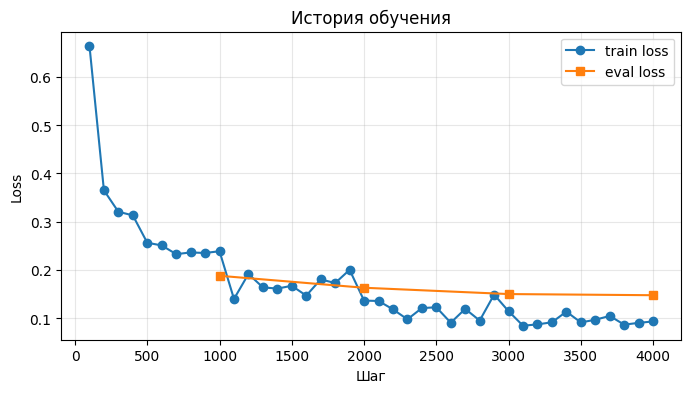

In [15]:
# История логов Trainer.
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("artifacts/training_curves.png")
plt.show()

In [16]:
# В transformers >= 5.x NotebookProgressCallback теряет состояние после обучения,
# что вызывает RuntimeError при вызове evaluate() вне тренировочного цикла.
# Удаляем его перед standalone-оценкой – это стандартный обходной путь.
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

set_seed()

# Оценка Trainer на validation и test.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

d:\_Programming\VS_Code\mirea-dpo-aie\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\_Programming\VS_Code\mirea-dpo-aie\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:
eval_loss: 0.1480
eval_accuracy: 0.9415
eval_f1_macro: 0.9163
eval_f1_weighted: 0.9414
eval_runtime: 23.0219
eval_samples_per_second: 86.8740
eval_steps_per_second: 5.4300
epoch: 4.0000

Test metrics:
eval_loss: 0.1914
eval_accuracy: 0.9315
eval_f1_macro: 0.8878
eval_f1_weighted: 0.9316
eval_runtime: 22.5725
eval_samples_per_second: 88.6030
eval_steps_per_second: 5.5380
epoch: 4.0000


d:\_Programming\VS_Code\mirea-dpo-aie\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification report on test:
              precision    recall  f1-score   support

     sadness       0.96      0.97      0.96       581
         joy       0.97      0.94      0.95       695
        love       0.81      0.88      0.84       159
       anger       0.94      0.92      0.93       275
        fear       0.88      0.92      0.90       224
    surprise       0.78      0.70      0.74        66

    accuracy                           0.93      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.93      0.93      0.93      2000



,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.9997
1,im updating my blog because i feel shitty,sadness,sadness,0.9997
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.9995
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.9996
4,i was feeling a little vain when i did this one,sadness,sadness,0.9996
5,i cant walk into a shop anywhere where i do not feel uncomfortable,fear,fear,0.9990
6,i felt anger when at the end of a telephone call,anger,anger,0.9987
7,i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have be...,joy,love,0.5953
8,i like to have the same breathless feeling as a reader eager to see what will happen next,joy,joy,0.9995
9,i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as fit as a walrus on ...,anger,anger,0.9994


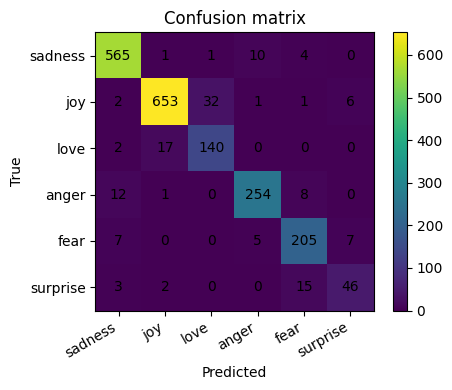

In [17]:
# Детальные предсказания на тестовой выборке.
set_seed()
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=[id2label[i] for i in range(len(id2label))],
        zero_division=0,
    )
)

rows = []
for i in range(10):
    rows.append({
        "text": dataset_dict["test"]["text"][i],
        "true_label": id2label[test_true[i]],
        "pred_label": id2label[test_preds[i]],
        "confidence": float(np.max(
            np.exp(test_logits[i]) / np.exp(test_logits[i]).sum()
        ))
    })

pd.DataFrame(rows)
predictions=pd.DataFrame(rows)
display(predictions)
predictions.to_csv("artifacts/sample_predictions.csv")


cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png")
plt.show()
